# ILUSTR 2 — Złożoność obliczeniowa metod algebraicznych: pełna macierz vs trójkątna, i po co rozkładać na LU

W poprzednim notebooku (ILUSTR1) budowaliśmy i rozwiązywaliśmy układy $A\mathbf{x}=\mathbf{b}$, nie przejmując się tym, ile to właściwie kosztuje. Tutaj pokazujemy, dlaczego sposób rozwiązania ma znaczenie — nie tylko *czy* dostaniemy wynik, ale *jak szybko*.

Dwie demonstracje:
1. **Pełna macierz vs macierz trójkątna** — rozwiązanie układu trójkątnego (samo podstawianie) jest dużo tańsze niż rozwiązanie układu pełnego (eliminacja + podstawianie). To pokazuje, *dlaczego w ogóle opłaca się* sprowadzać układ do postaci trójkątnej.
2. **Rozkład LU raz, a nie za każdym razem** — jeśli macierz $A$ się nie zmienia, a zmieniają się tylko kolejne $\mathbf{b}$, opłaca się rozłożyć $A$ na czynniki trójkątne ($L$, $U$) tylko raz, a potem dla każdego $\mathbf{b}$ wykonać już tylko tanie podstawianie.

Przy okazji Demo 1: dwa krótkie dodatki -- ile czasu zajęłoby to dla układu rzędu milionów równań (ekstrapolacja), i ile PAMIĘCI zajmuje sama macierz $A$ (drugi, równie namacalny koszt zasobowy obok czasu).

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
# Wylaczamy wielowatkowosc BLAS -- inaczej dla malych n narzut na
# uruchomienie watkow zafalszowalby porownanie (male ukdady wygladalyby
# nieproporcjonalnie wolno), zasloniajac czysty obraz roznicy O(n^3) vs O(n^2).

import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular, lu_factor, lu_solve

## Demo 1: pełna macierz vs macierz trójkątna

Rozwiązanie układu $A\mathbf{x}=\mathbf{b}$ dla **pełnej** (gęstej) macierzy $A$ metodą eliminacji Gaussa kosztuje $O(n^3)$ operacji — większość tego kosztu to sama eliminacja (sprowadzenie do postaci trójkątnej), nie samo podstawianie.

Jeśli macierz jest **już trójkątna** (np. dolna trójkątna $L$), eliminacja w ogóle nie jest potrzebna — zostaje tylko podstawianie, które kosztuje $O(n^2)$ operacji, czyli o cały jeden rząd wielkości mniej.

Poniżej mierzymy rzeczywisty czas obu podejść dla rosnącego rozmiaru układu $n$.

In [2]:
def czas_pelnej(n, powtorzenia=5, seed=0):
    rng = np.random.default_rng(seed)
    A = rng.random((n, n)) + n * np.eye(n)   # gesta, dobrze uwarunkowana (dominacja przekatnej)
    b = rng.random(n)
    np.linalg.solve(A, b)                     # "rozgrzewkowe" wywolanie, nie liczone do pomiaru
    czasy = []
    for _ in range(powtorzenia):
        start = time.perf_counter()
        np.linalg.solve(A, b)                 # pelna eliminacja Gaussa za kazdym razem
        czasy.append(time.perf_counter() - start)
    return np.median(czasy)                   # mediana -- odporna na pojedynczy "pechowy" pomiar


def czas_trojkatnej(n, powtorzenia=5, seed=0):
    rng = np.random.default_rng(seed)
    L = np.tril(rng.random((n, n))) + n * np.eye(n)   # dolna trojkatna, dobrze uwarunkowana
    b = rng.random(n)
    solve_triangular(L, b, lower=True)        # rozgrzewka
    czasy = []
    for _ in range(powtorzenia):
        start = time.perf_counter()
        solve_triangular(L, b, lower=True)    # samo podstawianie, bez eliminacji
        czasy.append(time.perf_counter() - start)
    return np.median(czasy)


rozmiary = [100, 200, 400, 800, 1200, 1600, 2000, 5000, 8000, 10000]
czasy_pelnej = [czas_pelnej(n) for n in rozmiary]
czasy_trojkatnej = [czas_trojkatnej(n) for n in rozmiary]

for n, tp, tt in zip(rozmiary, czasy_pelnej, czasy_trojkatnej):
    print(f"n={n:5d}   pelna: {tp*1000:7.3f} ms   trojkatna: {tt*1000:7.3f} ms   stosunek: {tp/tt:5.1f}x")

n=  100   pelna:   0.088 ms   trojkatna:   0.033 ms   stosunek:   2.7x
n=  200   pelna:   0.341 ms   trojkatna:   0.049 ms   stosunek:   7.0x
n=  400   pelna:   1.815 ms   trojkatna:   0.104 ms   stosunek:  17.5x
n=  800   pelna:  11.111 ms   trojkatna:   0.319 ms   stosunek:  34.8x
n= 1200   pelna:  34.846 ms   trojkatna:   0.671 ms   stosunek:  51.9x
n= 1600   pelna:  85.957 ms   trojkatna:   1.410 ms   stosunek:  61.0x
n= 2000   pelna: 154.915 ms   trojkatna:   3.418 ms   stosunek:  45.3x
n= 5000   pelna: 2091.751 ms   trojkatna:  27.810 ms   stosunek:  75.2x
n= 8000   pelna: 8222.099 ms   trojkatna:  76.153 ms   stosunek: 108.0x
n=10000   pelna: 15633.762 ms   trojkatna: 116.411 ms   stosunek: 134.3x


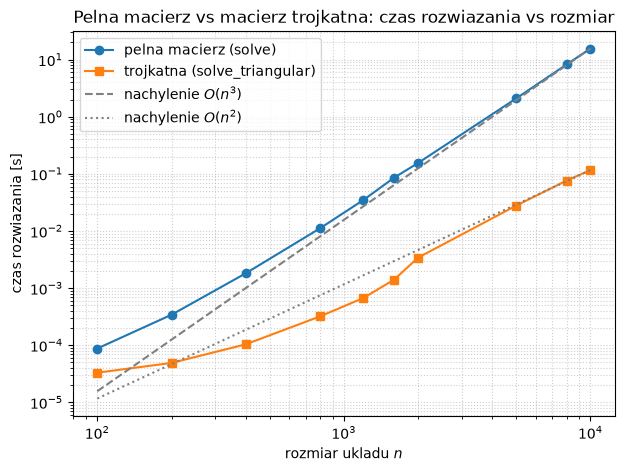

Przy n=10000: macierz trojkatna jest 134x szybsza od pelnej.


In [3]:
rozmiary_arr = np.array(rozmiary, dtype=float)
czasy_pelnej_arr = np.array(czasy_pelnej)
czasy_trojkatnej_arr = np.array(czasy_trojkatnej)

# Linie odniesienia n^2/n^3 zaczepione w OSTATNIM (najwiekszym) punkcie pomiaru --
# tam czas juz naprawde odzwierciedla sam koszt obliczen, a nie staly narzut
# wywolania funkcji, ktory potrafi zaklamac pomiar dla najmniejszych n (podobny efekt
# omawiamy w uwadze pod Demo 2 nizej).
n_ref = np.array([rozmiary_arr[0], rozmiary_arr[-1]])
ref_n3 = czasy_pelnej_arr[-1] * (n_ref / rozmiary_arr[-1]) ** 3
ref_n2 = czasy_trojkatnej_arr[-1] * (n_ref / rozmiary_arr[-1]) ** 2

plt.figure(figsize=(7, 5))
plt.loglog(rozmiary_arr, czasy_pelnej_arr, 'o-', label='pelna macierz (solve)')
plt.loglog(rozmiary_arr, czasy_trojkatnej_arr, 's-', label='trojkatna (solve_triangular)')
plt.loglog(n_ref, ref_n3, '--', color='gray', label=r'nachylenie $O(n^3)$')
plt.loglog(n_ref, ref_n2, ':', color='gray', label=r'nachylenie $O(n^2)$')
plt.xlabel('rozmiar ukladu $n$')
plt.ylabel('czas rozwiazania [s]')
plt.title('Pelna macierz vs macierz trojkatna: czas rozwiazania vs rozmiar')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()

print(f"Przy n={rozmiary[-1]}: macierz trojkatna jest {czasy_pelnej_arr[-1]/czasy_trojkatnej_arr[-1]:.0f}x szybsza od pelnej.")

In [4]:
C_czas = np.median(czasy_pelnej_arr / rozmiary_arr ** 3)
n_duze = 10_000_000
t_duze_s = C_czas * n_duze ** 3
ROK = 365.25 * 24 * 3600
print(f"Ekstrapolacja (dopasowane t=C*n^3, C={C_czas:.3e}): dla n={n_duze:.0e} czas ~ {t_duze_s:.3e} s = {t_duze_s/ROK:,.0f} lat")

Ekstrapolacja (dopasowane t=C*n^3, C=1.886e-10): dla n=1e+07 czas ~ 1.886e+11 s = 5,977 lat


## Ile pamięci zajmuje pełna (gęsta) macierz A?

Obok czasu, drugi namacalny koszt zasobowy pełnej macierzy to **pamięć**: gęsta macierz $n\times n$ przechowuje $n^2$ elementów (8 bajtów każdy w podwójnej precyzji), niezależnie od tego, ile z nich jest w praktyce potrzebnych — rośnie to szybciej, niż się intuicyjnie wydaje.

       n     pamiec (double)
   1e+02               80 KB
   1e+03                8 MB
   1e+04              800 MB
   1e+05               80 GB
   1e+06                8 TB
   1e+07              800 TB


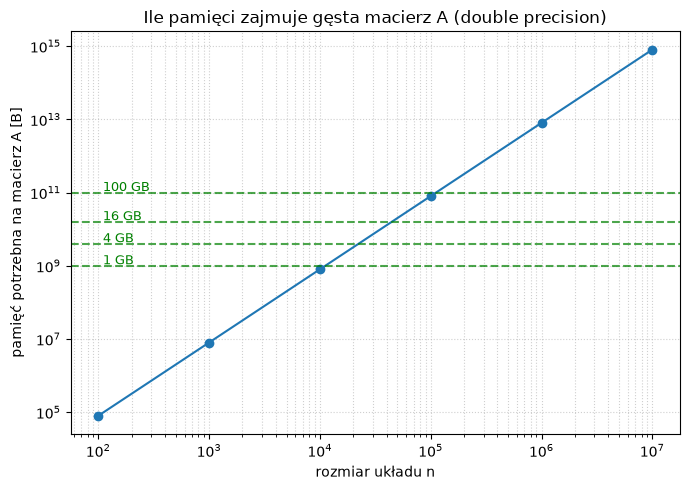

In [5]:
rozmiary_pamiec = np.array([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
GB = 1e9

def tekst_pamieci(bajty):
    for jednostka, factor in [('TB', 1e12), ('GB', 1e9), ('MB', 1e6), ('KB', 1e3)]:
        if bajty >= factor:
            return f"{bajty/factor:.3g} {jednostka}"
    return f"{bajty:.0f} B"

print(f"{'n':>8}{'pamiec (double)':>20}")
for n_pam in rozmiary_pamiec:
    print(f"{n_pam:8.0e}{tekst_pamieci(8*n_pam**2):>20}")

plt.figure(figsize=(7, 5))
plt.loglog(rozmiary_pamiec, 8*rozmiary_pamiec**2, 'o-')
progi_pam = np.array([1, 4, 16, 100]) * GB
for p in progi_pam:
    plt.axhline(p, color='green', linestyle='--', alpha=0.7)
    plt.text(rozmiary_pamiec[0]*1.1, p*1.1, f'{p/GB:.0f} GB', color='green', fontsize=9)
plt.xlabel('rozmiar układu n')
plt.ylabel('pamięć potrzebna na macierz A [B]')
plt.title('Ile pamięci zajmuje gęsta macierz A (double precision)')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Przy $n=10^5$ (duża siatka MES) sama macierz $A$ zajęłaby już ok. 80 GB -- niepraktyczne na typowym komputerze, a przy $n=10^6$ to już 8 TB. To **drugi** (obok czasu $O(n^3)$) powód, dla którego duże układy z dyskretyzacji równań różniczkowych rozwiązuje się metodami wykorzystującymi **rzadkość** macierzy (patrz ILUSTR4 -- macierz rzadka z siatki Poissona), zamiast trzymać je jako pełne, gęste macierze.

Różnica rośnie z rozmiarem układu — to właśnie różnica między $O(n^3)$ a $O(n^2)$: przy dwukrotnie większym $n$ pełna macierz kosztuje ~8x więcej, a trójkątna tylko ~4x więcej. **Jest więc o co walczyć.**

Skoro układ trójkątny jest tak tani, nasuwa się pytanie: czy da się sprowadzić macierz $A$ do takiej trójkątnej postaci **raz**, a potem korzystać z tego rozłożenia wielokrotnie? To jest ogólna idea **każdego rozkładu macierzy** (LU, QR, Cholesky, ...) — różnią się one tym, na jakie czynniki rozkładają $A$ i dla jakich macierzy się nadają, ale wszystkie dzielą koszt na drogi krok wstępny (rozkład, raz) i tanie rozwiązanie końcowe (wielokrotnie). Najprostszym i najtańszym takim rozkładem dla dowolnej (ogólnej, kwadratowej) macierzy jest **rozkład LU** ($A = LU$, gdzie $L$ jest dolną trójkątną, a $U$ górną trójkątną macierzą) — poniżej pokazujemy na nim, kiedy i dlaczego to się opłaca.

## Demo 2: rozkład LU raz, a nie za każdym razem

Wyobraźmy sobie sytuację podobną do tej z notebooka ILUSTR1 (macierz obrotu): mamy ustaloną macierz $A$, a dane napływają pojedynczo jako kolejne wektory $\mathbf{b}$ (np. w czasie rzeczywistym, klatka po klatce z sensora) i nie można ich z góry skleić w jedną macierz. Rozwiązujemy więc układ pojedynczo, punkt po punkcie — ale macierz $A$ pozostaje przez cały czas **ta sama**.

To jest dokładnie sytuacja, w której opłaca się rozłożyć $A$ na czynniki **tylko raz** — tu akurat na czynniki LU, bo $A$ jest ogólną macierzą kwadratową bez szczególnych właściwości — a potem dla każdego kolejnego $\mathbf{b}$ wykonać już tylko tanie podstawianie (koszt rzędu $O(n^2)$, tak jak w Demo 1 powyżej), zamiast za każdym razem liczyć cały rozkład od nowa (koszt rzędu $O(n^3)$). Poniżej porównujemy czas obu podejść na dużej liczbie punktów.

**UWAGA! To może chwilę potrwać!**

In [6]:
# Uzywamy tu WIEKSZEJ macierzy A_test (100x100) zamiast naszej macierzy obrotu 3x3 --
# przy tak malym ukladzie jak 3x3 koszt eliminacji jest zbyt mikroskopijny, zeby
# przewaga LU byla w ogole widoczna (zobacz uwage pod kodem). Zeby zobaczyc realny
# efekt, potrzebny jest uklad blizszy praktycznym rozmiarom (grafika 3D, symulacje
# inzynierskie).
n_test = 200
rng = np.random.default_rng(1)
A_test = rng.random((n_test, n_test)) + n_test * np.eye(n_test)   # losowa, dobrze uwarunkowana macierz (dominacja przekątnej)

# Symulujemy N punktow naplywajacych pojedynczo (np. strumien danych z sensora) --
# ich konkretny sens jest tu bez znaczenia, liczy sie tylko czas rozwiazywania
N = 300
Y = rng.normal(size=(N, n_test))   # N losowych wektorow "po obrocie", wiersz = jeden punkt

# --- Podejscie 1: naiwne -- pelne rozwiazanie ukladu dla KAZDEGO punktu osobno ---
start = time.time()
X_naiwne = np.empty_like(Y)
for i in range(N):
    X_naiwne[i] = np.linalg.solve(A_test, Y[i])
czas_naiwny = time.time() - start

# --- Podejscie 2: rozklad LU macierzy A_test raz, potem tylko podstawianie dla kazdego punktu ---
start = time.time()
lu, piv = lu_factor(A_test)     # rozklad LU liczony JEDEN raz
X_lu = np.empty_like(Y)
for i in range(N):
    X_lu[i] = lu_solve((lu, piv), Y[i])   # tylko podstawianie, bez ponownej eliminacji
czas_lu = time.time() - start

print(f"Podejście naiwne (solve za każdym razem): {czas_naiwny:.4f} s")
print(f"Podejście z LU liczonym raz:              {czas_lu:.4f} s")
print(f"Przyspieszenie: {czas_naiwny/czas_lu:.1f}x")
print(f"Maks. różnica wyników obu podejść: {np.max(np.abs(X_naiwne - X_lu)):.2e}")

Podejście naiwne (solve za każdym razem): 0.1064 s
Podejście z LU liczonym raz:              0.0103 s
Przyspieszenie: 10.4x
Maks. różnica wyników obu podejść: 0.00e+00


**Uwaga.** Dla małej macierzy obrotu $3\times 3$ z ILUSTR1 (spróbuj podstawić ją tutaj zamiast `A_test`) ta sama przewaga LU byłaby niewidoczna, a nawet odwrócona — przy tak małym $n$ koszt eliminacji ($O(n^3)$) jest tak mikroskopijny, że każde wywołanie funkcji (sprawdzanie argumentów, Python, LAPACK) niesie własny, stały narzut, który z nawiązką przebija cały teoretyczny zysk z pominięcia eliminacji. Dopiero przy $n$ rzędu dziesiątek/setek koszt eliminacji zaczyna faktycznie dominować nad tym narzutem — zobacz ćwiczenie 1 niżej.

## Najważniejsze wnioski

- Nie każdy sposób rozwiązania $A\mathbf{x}=\mathbf{b}$ kosztuje tyle samo: pełna eliminacja to $O(n^3)$, samo podstawianie w układzie trójkątnym to $O(n^2)$ — to realna, rosnąca z rozmiarem różnica (Demo 1).
- Rozłożenie macierzy na czynniki (tu: LU) raz i wielokrotne, tanie podstawianie zamiast pełnego rozwiązywania od nowa — to ogólna idea wspólna dla **każdego** rozkładu macierzy (LU, QR, Cholesky, ...), nie tylko LU; LU jest tu po prostu najtańszym, uniwersalnym wyborem dla dowolnej macierzy kwadratowej. Opłaca się, gdy macierz $A$ jest stała, a zmienia się $\mathbf{b}$ (Demo 2). Inne rozkłady (QR, Cholesky) mają tę samą własność, ale wybiera się je z innych powodów — patrz kolejny notebook (ILUSTR3).
- Efekt jest widoczny dopiero dla układów odpowiednio dużych — dla bardzo małych $n$ (np. naszej macierzy obrotu $3\times 3$ z ILUSTR1) stały narzut wywołania funkcji przebija teoretyczny zysk.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.linalg.solve(A, b)` | Rozwiązuje układ $Ax=b$ od nowa (pełna eliminacja za każdym razem) |
| `scipy.linalg.solve_triangular(L, b, lower=True)` | Rozwiązuje układ trójkątny samym podstawianiem, bez eliminacji |
| `scipy.linalg.lu_factor(A)` | Liczy rozkład LU macierzy $A$ (raz) |
| `scipy.linalg.lu_solve((lu, piv), b)` | Rozwiązuje układ, korzystając z gotowego rozkładu LU (tylko podstawianie) |
| `time.perf_counter()` / `time.time()` | Znacznik czasu do pomiaru wydajności |

## ĆWICZENIE

1. Podstaw z powrotem oryginalną macierz obrotu $3\times 3$ z ILUSTR1 (zamiast `A_test`) w porównaniu z Demo 2 i sprawdź, czy przyspieszenie znika lub się odwraca. Metodą prób i błędów znajdź w przybliżeniu najmniejszy rozmiar $n$, dla którego przewaga LU staje się wyraźnie widoczna (powiedzmy: przyspieszenie > 2×).
2. Co się stanie, jeśli macierz $A$ jest **inna dla każdego punktu** (zmienia się za każdym razem)? Zaimplementuj taki wariant Demo 2 i sprawdź, czy podejście z rozkładem LU nadal się opłaca. Dlaczego tak / dlaczego nie?
3. W Demo 1 sprawdź, czy stosunek czasów nadal rośnie w przybliżeniu proporcjonalnie do $n$ (bo $n^3/n^2=n$) przy jeszcze większych rozmiarach (np. `rozmiary` do 20000). Dlaczego pomiary dla najmniejszych $n$ (100, 200) leżą wyraźnie poniżej linii nachylenia teoretycznego — co dominuje czas wykonania przy tak małych układach, skoro sam koszt eliminacji jest tam mikroskopijny?